### https://www.kaggle.com/datasets/zubairmustafa/shopping-mall-customer-segmentation-data
* This dataset is designed for learning customer segmentation concepts, such as market basket analysis. It includes basic customer data such as Customer ID, age, gender, annual income, and spending score, which is assigned based on customer behavior and purchasing data. The goal is to help a supermarket mall owner understand their customers better, identify target customers who are likely to converge, and provide insights to the marketing team for strategic planning.

In [1]:
import kagglehub
import shutil
import os

# Download latest version
download_path = kagglehub.dataset_download("zubairmustafa/shopping-mall-customer-segmentation-data")

# 2. Đường dẫn thư mục muốn lưu (Ví dụ: thư mục 'data' ngay tại thư mục code hiện tại)
target_path = "../data/raw"

# 3. Copy toàn bộ dữ liệu sang thư mục mới
if os.path.exists(target_path):
    shutil.rmtree(target_path) # Xóa nếu thư mục đã tồn tại để tránh lỗi
shutil.copytree(download_path, target_path)

print("Dữ liệu đã được lưu tại:", os.path.abspath(target_path))

C:\Users\Win 11\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dữ liệu đã được lưu tại: C:\Users\Win 11\Documents\ML\ML_proj_26\lab3\data\raw


# Phân Tích Khám Phá Dữ Liệu (Exploratory Data Analysis - EDA) -

Mục tiêu của notebook này là tiến hành phân tích khám phá dữ liệu (EDA) trên tập dữ liệu (`shopping-mall-customer-segmentation-data.csv`), tuân thủ theo các bước hướng dẫn trong `eda_guide.md`.

**Lưu ý:** Trong giai đoạn này, chúng ta tập trung hoàn toàn vào việc khám phá, trực quan hóa và nhận diện các bất thường dữ liệu. Không thực hiện bất kỳ thay đổi in-place hay tiền xử lý làm sạch dữ liệu nào trên tập dữ liệu gốc.

## Bước 1. Tổng Quan Dữ Liệu & Kiểu Dữ Liệu (Data Overview & Data Types)

Trong bước này, chúng ta sẽ tải thư viện, kiểm tra quy mô bộ dữ liệu (số hàng, số cột), kiểu dữ liệu các cột và xem trước một số dòng dữ liệu mẫu.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Thiết lập phong cách hiển thị biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Đường dẫn đến file dữ liệu
data_path = '../data/raw/Shopping Mall Customer Segmentation Data .csv'
df = pd.read_csv(data_path)

# Kích thước dữ liệu
print(f"Kích thước bộ dữ liệu: {df.shape[0]:,} hàng, {df.shape[1]} cột")

Kích thước bộ dữ liệu: 15,079 hàng, 5 cột


In [3]:
# Xem thông tin kiểu dữ liệu và số lượng non-null
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Customer ID     15079 non-null  str  
 1   Age             15079 non-null  int64
 2   Gender          15079 non-null  str  
 3   Annual Income   15079 non-null  int64
 4   Spending Score  15079 non-null  int64
dtypes: int64(3), str(2)
memory usage: 1.2 MB


In [4]:
# Xem 5 dòng đầu tiên
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [5]:
# Xem 5 dòng cuối cùng
df.tail()

,Customer ID,Age,Gender,Annual Income,Spending Score
15074,a0504768-a85f-4930-ac24-55bc8e4fec9e,29,Female,97723,30
15075,a08c4e0e-d1fe-48e7-9366-aab11ae409cd,22,Male,73361,74
15076,0e87c25a-268c-401a-8ba1-7111dcde6f1a,18,Female,112337,48
15077,5f388cbe-3373-4e16-b743-38f508f2249f,26,Female,94312,5
15078,b8b8f561-ebca-4401-8afe-544c906554ba,19,Male,78045,2


In [6]:
# Xem ngẫu nhiên 5 dòng dữ liệu
df.sample(5, random_state=42)

,Customer ID,Age,Gender,Annual Income,Spending Score
5404,73ebeee3-01c6-4ffc-8a7f-bf81391443a4,44,Female,167902,82
3613,81a16720-019a-4bc7-91c4-1e04e69d81d5,39,Female,102743,26
12127,e1034276-ecee-4b46-85e8-8d423f7f035e,48,Female,116714,47
9941,009dcc8f-bc1f-4476-8996-3b5d5ddaaebe,73,Male,98545,10
5221,cb8f9402-8952-43c6-be01-e5c6c1062d90,34,Female,119152,33


## Bước 2. Thống Kê Tổng Hợp (Summary Statistics)

Chúng ta sẽ tính toán các chỉ số thống kê mô tả (trung bình, trung vị, độ lệch chuẩn, phân vị, giá trị lớn nhất, nhỏ nhất, số lượng giá trị duy nhất) cho cả biến số và biến phân loại.

In [7]:
# Thống kê mô tả các biến số (Numerical Features)
df.describe()

,Age,Annual Income,Spending Score
count,15079.000000,15079.000000,15079.000000
mean,54.191591,109742.880562,50.591617
std,21.119207,52249.425866,28.726977
min,18.000000,20022.000000,1.000000
25%,36.000000,64141.000000,26.000000
50%,54.000000,109190.000000,51.000000
75%,72.000000,155008.000000,75.000000
max,90.000000,199974.000000,100.000000


In [8]:
# Thống kê mô tả các biến phân loại (Categorical Features)
df.describe(include=['O'])

C:\Users\Win 11\AppData\Local\Temp\ipykernel_20904\3568426033.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['O'])


,Customer ID,Gender
count,15079,15079
unique,15079,2
top,d410ea53-6661-42a9-ad3a-f554b05fd2a7,Male
freq,1,7595


## Bước 3. Phân Tích Đơn Biến & Phân Phối (Univariate Analysis & Distributions)

Chúng ta khảo sát phân phối của từng đặc trưng một cách độc lập:
1. **Biến số:** Tuổi (`Age`), Thu nhập hàng năm (`Annual Income`), Điểm chi tiêu (`Spending Score`). Vẽ biểu đồ Histogram kết hợp đường KDE để xem dạng phân phối và độ lệch.
2. **Biến phân loại:** Giới tính khách hàng (`Gender`). Vẽ biểu đồ cột để xem số lượng và tỷ lệ giữa Nam và Nữ.

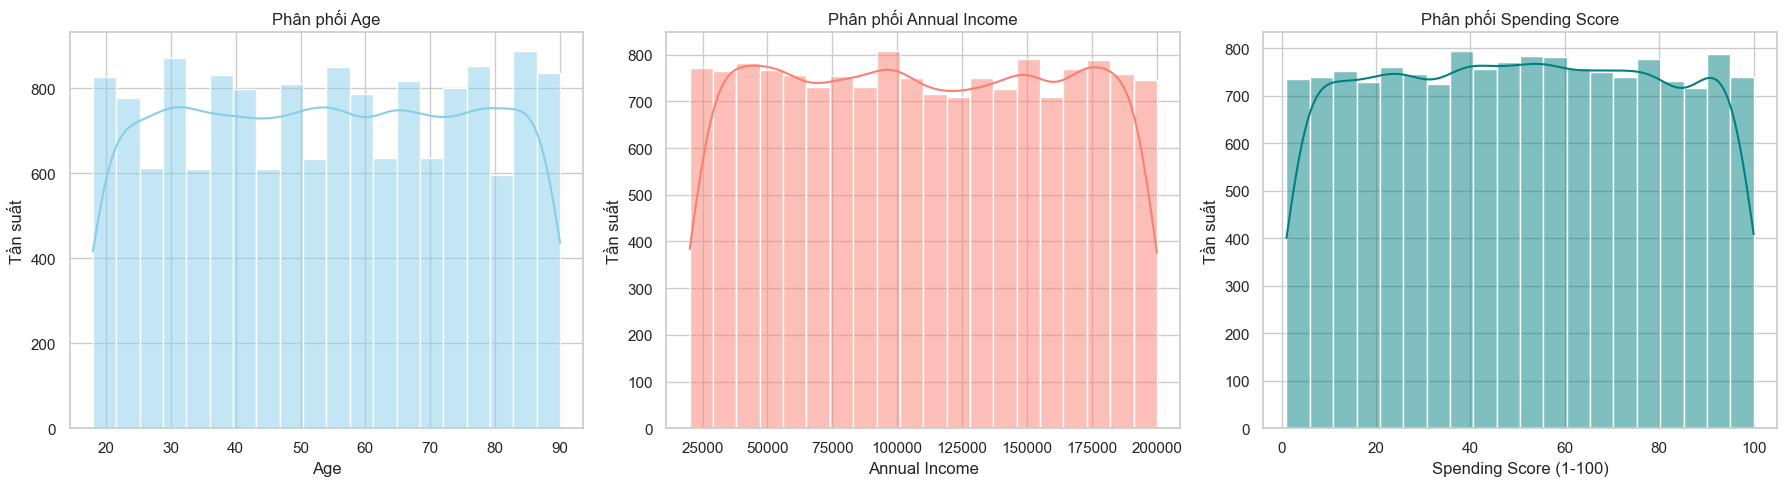

In [9]:
# 1. Vẽ phân phối của các biến số: Age, Annual Income, Spending Score
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Phân phối Age
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Tần suất')

# Phân phối Annual Income
sns.histplot(df['Annual Income'], bins=20, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Phân phối Annual Income')
axes[1].set_xlabel('Annual Income')
axes[1].set_ylabel('Tần suất')

# Phân phối Spending Score
sns.histplot(df['Spending Score'], bins=20, kde=True, ax=axes[2], color='teal')
axes[2].set_title('Phân phối Spending Score')
axes[2].set_xlabel('Spending Score (1-100)')
axes[2].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

C:\Users\Win 11\AppData\Local\Temp\ipykernel_20904\4116122860.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='pastel')


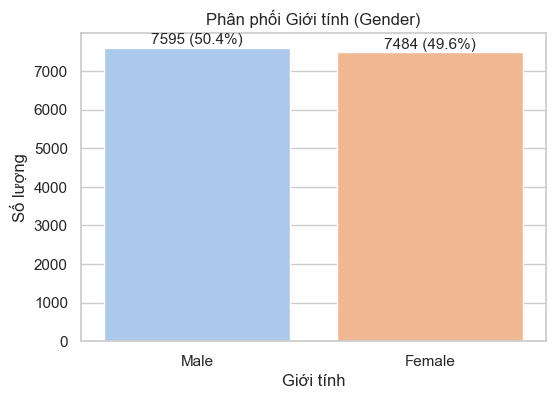

In [10]:
# 2. Phân tích biến phân loại Gender
plt.figure(figsize=(6, 4))
gender_counts = df['Gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='pastel')
plt.title('Phân phối Giới tính (Gender)')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')
for i, val in enumerate(gender_counts.values):
    plt.text(i, val + 100, f"{val} ({val/len(df)*100:.1f}%)", ha='center')
plt.show()

## Bước 4. Phân Tích Song Biến & Tương Quan (Bivariate Analysis & Correlation)

Chúng ta khảo sát mối quan hệ giữa các cặp biến:
1. **Annual Income vs. Spending Score (Số vs Số):** Biểu đồ tán xạ (Scatter Plot) để phát hiện xu hướng phân cụm của khách hàng.
2. **Age vs. Spending Score / Annual Income (Số vs Số):** Xem tuổi tác ảnh hưởng thế nào đến thu nhập và mức chi tiêu.
3. **Gender vs. Annual Income / Spending Score (Số vs Phân loại):** Vẽ boxplot để so sánh phân phối giữa các nhóm giới tính.
4. **Ma trận tương quan:** Hệ số tương quan Pearson giữa các đặc trưng số.

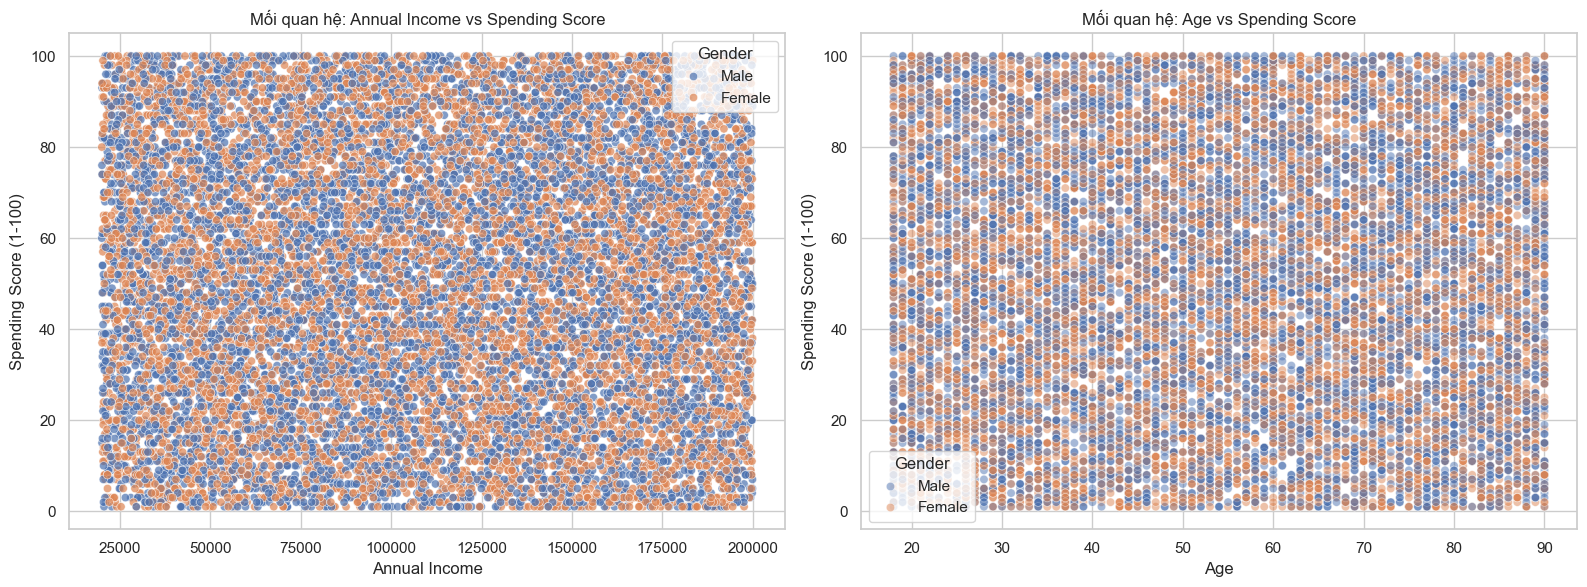

In [11]:
# 1. Vẽ mối quan hệ giữa các cặp biến số
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Annual Income vs Spending Score
sns.scatterplot(data=df, x='Annual Income', y='Spending Score', hue='Gender', alpha=0.7, ax=axes[0])
axes[0].set_title('Mối quan hệ: Annual Income vs Spending Score')
axes[0].set_xlabel('Annual Income')
axes[0].set_ylabel('Spending Score (1-100)')

# Age vs Spending Score
sns.scatterplot(data=df, x='Age', y='Spending Score', hue='Gender', alpha=0.5, ax=axes[1])
axes[1].set_title('Mối quan hệ: Age vs Spending Score')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

C:\Users\Win 11\AppData\Local\Temp\ipykernel_20904\3159463846.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Annual Income', palette='pastel', ax=axes[0])
C:\Users\Win 11\AppData\Local\Temp\ipykernel_20904\3159463846.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Spending Score', palette='pastel', ax=axes[1])


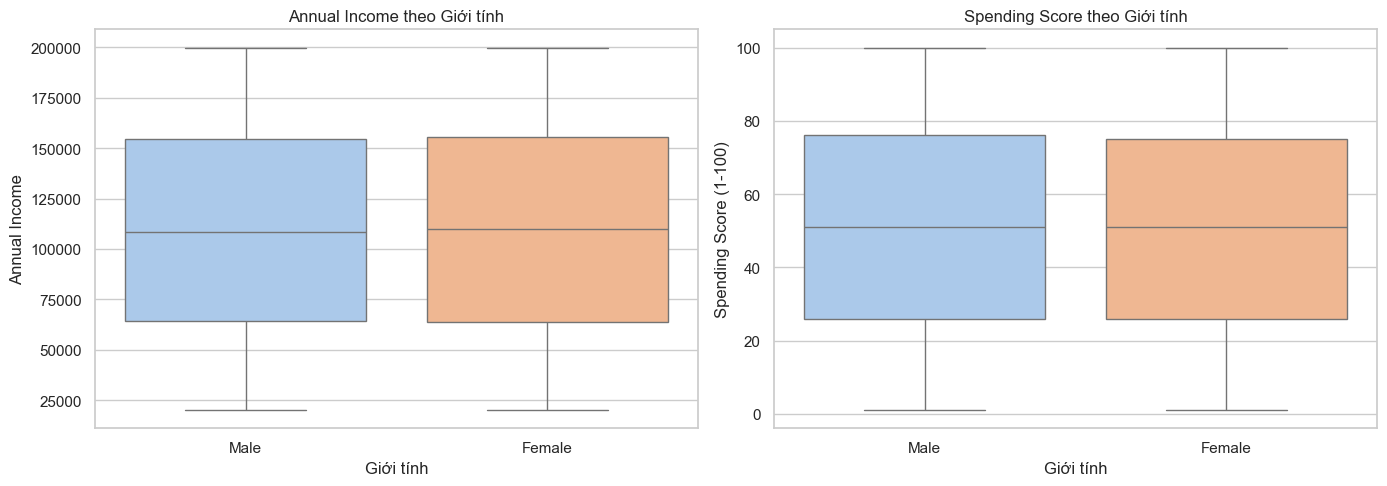

In [12]:
# 2. So sánh Annual Income và Spending Score theo Gender sử dụng Box plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender vs Annual Income
sns.boxplot(data=df, x='Gender', y='Annual Income', palette='pastel', ax=axes[0])
axes[0].set_title('Annual Income theo Giới tính')
axes[0].set_xlabel('Giới tính')
axes[0].set_ylabel('Annual Income')

# Gender vs Spending Score
sns.boxplot(data=df, x='Gender', y='Spending Score', palette='pastel', ax=axes[1])
axes[1].set_title('Spending Score theo Giới tính')
axes[1].set_xlabel('Giới tính')
axes[1].set_ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

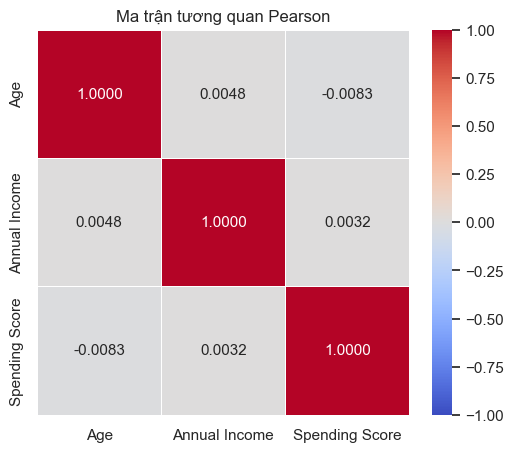

In [13]:
# 3. Tính toán và trực quan hóa ma trận tương quan Pearson
corr_matrix = df[['Age', 'Annual Income', 'Spending Score']].corr(method='pearson')

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Ma trận tương quan Pearson')
plt.show()

## Bước 5. Nhận Diện Dữ Liệu Thiếu, Trùng Lặp & Ngoại Lệ (Missing Data, Duplicate Data & Outliers)

Chúng ta kiểm tra chất lượng dữ liệu thông qua:
1. Đếm giá trị thiếu (Null values) và dòng trùng lặp (Duplicate rows).
2. Phát hiện các điểm ngoại lệ (Outliers) cho các cột số bằng phương pháp IQR và Z-Score.

--- DỮ LIỆU THIẾU ---
Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

Số lượng dòng trùng lặp hoàn toàn: 0 dòng
Số lượng ID khách hàng duy nhất: 15,079

--- NGOẠI LỆ CHO CỘT: Age ---
Khoảng IQR không ngoại lệ: [-18.00, 126.00]
Số lượng ngoại lệ (IQR): 0 (0.00%)

--- NGOẠI LỆ CHO CỘT: Annual Income ---
Khoảng IQR không ngoại lệ: [-72159.50, 291308.50]
Số lượng ngoại lệ (IQR): 0 (0.00%)

--- NGOẠI LỆ CHO CỘT: Spending Score ---
Khoảng IQR không ngoại lệ: [-47.50, 148.50]
Số lượng ngoại lệ (IQR): 0 (0.00%)


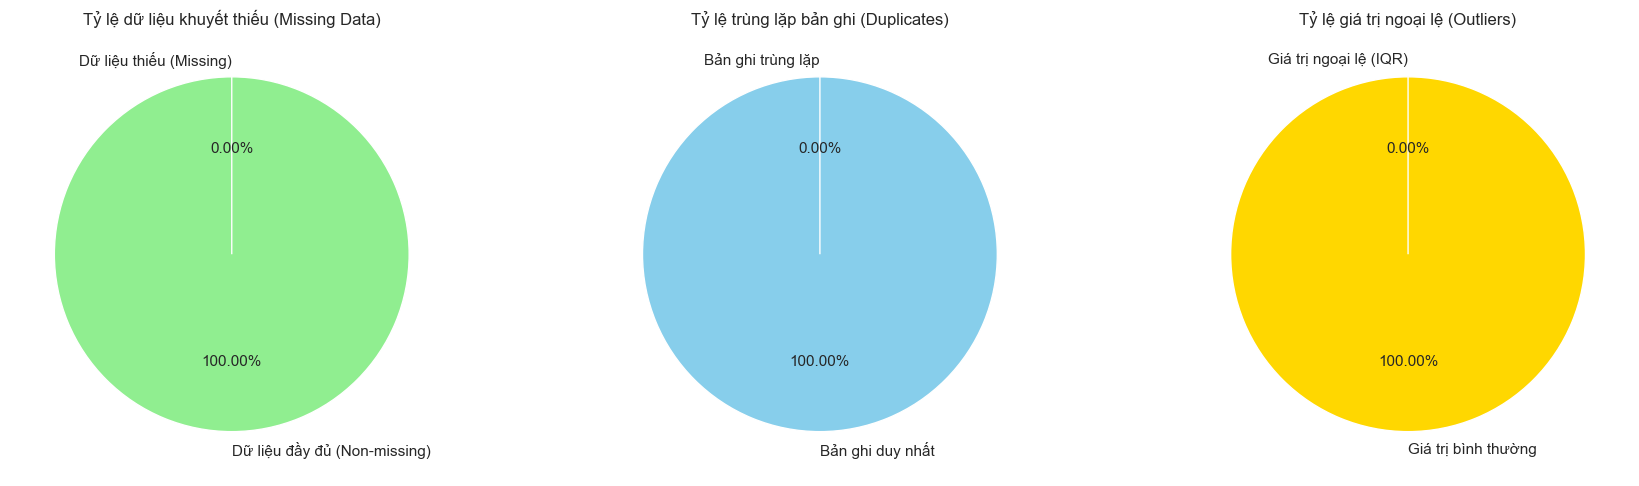

In [14]:
# 1. Kiểm tra dữ liệu thiếu và trùng lặp
print("--- DỮ LIỆU THIẾU ---")
print(df.isnull().sum())
print(f"\nSố lượng dòng trùng lặp hoàn toàn: {df.duplicated().sum()} dòng")
print(f"Số lượng ID khách hàng duy nhất: {df['Customer ID'].nunique():,}")

# 2. Hàm phát hiện Outliers bằng IQR và Z-score
def get_outliers_count(series):
    series_clean = series.dropna()
    
    # Phương pháp khoảng IQR
    q1 = series_clean.quantile(0.25)
    q3 = series_clean.quantile(0.75)
    iqr = q3 - q1
    lower_iqr = q1 - 1.5 * iqr
    upper_iqr = q3 + 1.5 * iqr
    count_iqr = ((series_clean < lower_iqr) | (series_clean > upper_iqr)).sum()
    
    return count_iqr, lower_iqr, upper_iqr

# Tính toán outlier cho từng cột số
for col in ['Age', 'Annual Income', 'Spending Score']:
    c_iqr, low, upp = get_outliers_count(df[col])
    print(f"\n--- NGOẠI LỆ CHO CỘT: {col} ---")
    print(f"Khoảng IQR không ngoại lệ: [{low:.2f}, {upp:.2f}]")
    print(f"Số lượng ngoại lệ (IQR): {c_iqr} ({c_iqr/len(df)*100:.2f}%)")

# 3. Trực quan hóa dữ liệu thiếu, trùng lặp và ngoại lệ dưới dạng biểu đồ tròn (Pie Charts)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Biểu đồ tròn cho Dữ liệu thiếu
missing_total = df.isnull().sum().sum()
total_elements = df.size
sizes_missing = [total_elements - missing_total, missing_total]
labels_missing = ['Dữ liệu đầy đủ (Non-missing)', 'Dữ liệu thiếu (Missing)']
colors_missing = ['lightgreen', 'red']
axes[0].pie(sizes_missing, labels=labels_missing, autopct='%1.2f%%', startangle=90, colors=colors_missing, explode=(0, 0.1) if missing_total > 0 else (0, 0))
axes[0].set_title('Tỷ lệ dữ liệu khuyết thiếu (Missing Data)')

# B. Biểu đồ tròn cho Dữ liệu trùng lặp
duplicate_total = df.duplicated().sum()
sizes_dup = [len(df) - duplicate_total, duplicate_total]
labels_dup = ['Bản ghi duy nhất', 'Bản ghi trùng lặp']
colors_dup = ['skyblue', 'orange']
axes[1].pie(sizes_dup, labels=labels_dup, autopct='%1.2f%%', startangle=90, colors=colors_dup, explode=(0, 0.1) if duplicate_total > 0 else (0, 0))
axes[1].set_title('Tỷ lệ trùng lặp bản ghi (Duplicates)')

# C. Biểu đồ tròn cho Dữ liệu ngoại lệ (Outliers) tổng hợp
total_outliers = 0
for col in ['Age', 'Annual Income', 'Spending Score']:
    c_iqr, _, _ = get_outliers_count(df[col])
    total_outliers += c_iqr

sizes_out = [len(df) * 3 - total_outliers, total_outliers]
labels_out = ['Giá trị bình thường', 'Giá trị ngoại lệ (IQR)']
colors_out = ['gold', 'crimson']
axes[2].pie(sizes_out, labels=labels_out, autopct='%1.2f%%', startangle=90, colors=colors_out, explode=(0, 0.1) if total_outliers > 0 else (0, 0))
axes[2].set_title('Tỷ lệ giá trị ngoại lệ (Outliers)')

plt.tight_layout()
plt.show()


## Bước 6. Đánh Giá Chất Lượng Dữ Liệu & Hướng Tiền Xử Lý (Data Quality & Next Steps)

In [15]:
# Tạo bảng DataFrame tổng hợp chất lượng dữ liệu và đề xuất xử lý tiếp theo
summary_data = []

for col in df.columns:
    dtype = str(df[col].dtype)
    missing = df[col].isnull().sum()
    missing_pct = (missing / len(df)) * 100
    unique_cnt = df[col].nunique()
    
    # Tính toán outlier nếu là cột số
    if df[col].dtype in [np.int64, np.float64]:
        c_iqr, _, _ = get_outliers_count(df[col])
        outliers_str = f"{c_iqr} (IQR)"
        if col in ['Annual Income', 'Spending Score']:
            action = "MinMaxScaler / StandardScaler (Quan trọng để thuật toán phân cụm K-Means hoạt động chính xác)"
        else:
            action = "Giữ nguyên hoặc Chia nhóm (Age Binning) nếu cần thiết"
    else:
        outliers_str = "N/A (Categorical)"
        if col == 'Gender':
            action = "Label Encoding (Male: 1, Female: 0)"
        else:
            action = "Bỏ qua / Chỉ dùng để định danh khách hàng (Customer ID)"
            
    summary_data.append({
        'Cột': col,
        'Kiểu dữ liệu': dtype,
        'Số dòng thiếu': missing,
        'Tỷ lệ thiếu (%)': f"{missing_pct:.2f}%",
        'Số giá trị duy nhất': unique_cnt,
        'Số lượng ngoại lệ': outliers_str,
        'Đề xuất tiền xử lý (Action)': action
    })

df_summary = pd.DataFrame(summary_data)
# Hiển thị bảng tổng hợp để đánh giá chất lượng dữ liệu
df_summary

,Cột,Kiểu dữ liệu,Số dòng thiếu,Tỷ lệ thiếu (%),Số giá trị duy nhất,Số lượng ngoại lệ,Đề xuất tiền xử lý (Action)
0,Customer ID,str,0,0.00%,15079,N/A (Categorical),Bỏ qua / Chỉ dùng để định danh khách hàng (Cus...
1,Age,int64,0,0.00%,73,0 (IQR),Giữ nguyên hoặc Chia nhóm (Age Binning) nếu cầ...
2,Gender,str,0,0.00%,2,N/A (Categorical),"Label Encoding (Male: 1, Female: 0)"
3,Annual Income,int64,0,0.00%,14441,0 (IQR),MinMaxScaler / StandardScaler (Quan trọng để t...
4,Spending Score,int64,0,0.00%,100,0 (IQR),MinMaxScaler / StandardScaler (Quan trọng để t...
